# CenMAP HOR Plot Customization - Split by Haplotype
 
This notebook customizes the HOR overview plots generated by the CenMAP pipeline.  
It splits samples by haplotype and creates separate plots with customized styling.

In [ ]:
import os
import re
import yaml
import copy
import json
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from collections import defaultdict
from pathlib import Path
from io import BytesIO


# Path to font (Liberation Sans: free, metric-compatible with Helvetica)
font_path = "../../doc/figures/helvetica/LiberationSans-Regular.ttf"

# Register the font
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Liberation Sans'

# Cenplot imports
from cenplot import plot_tracks, read_tracks

In [ ]:
# Input files from CenMAP output (adjust paths to your data)
INPUT_STV_BED = "../../analysis_other/cenmap/results/11-plot_hor_stv/bed/chr_stv_complete_chr5.bed"  # Merged STV annotation bed
INPUT_RM_BED = "../../analysis_other/cenmap/results/11-plot_hor_stv/bed/chr_sat_annot_chr5.bed"  # RepeatMasker satellite annotations
INPUT_CDR_BED = "../../analysis_other/cenmap/results/11-plot_hor_stv/bed/chr_cdr_chr5.bed"  # Optional: path to CDR bed file, set to None if not available

# Color map file for STV annotations (from CenMAP config)
STV_ANNOT_COLORS_FILE = "../../analysis_other/cenmap/config/stv_annot_colors.tsv"  # Set to path if you have a custom color map

# Output directory
OUTPUT_DIR = "../../doc/figures/hor_plots"

# Plot dimensions
PLOT_WIDTH_INCHES = 2.0  # Customizable width
TRACK_HEIGHT_PER_SAMPLE = 0.3  # Height per sample track

# Font settings
FONT_FAMILY = "Liberation Sans"
FONT_SIZE = 5
LABEL_FONT_SIZE = 5

# Haplotype detection pattern
# Adjust this regex if your naming convention differs
# Common patterns: "hap1/hap2", "h1/h2", "haplotype1/haplotype2", "mat/pat"
HAPLOTYPE_REGEX = r'(hap(?:lotype)?[12]|h[12]|mat|pat)'

# Grey background color for centromere tracks (matching CenMAP style)
BG_COLOR = "#E6E6E6"

CDR_COLOR = "#FF99F0"  # Orange color for CDR regions

# Arrow settings for HOR orientation
ARROW_SCALE = 5  # Smaller arrows (CenMAP uses 10-15, we use smaller for compact view)
ARROW_FWD_COLOR = "#252525"  # Black arrows as requested
ARROW_REV_COLOR = "#252525"  # Black arrows as requested

# Only show live HOR arrows (matching CenMAP default behavior)
LIVE_ONLY_ARROWS = True


In [32]:
# Define functions

def load_stv_color_map(filepath: str) -> dict[str, str]:
    """
    Load the STV annotation color map from TSV file.
    Format: monomer_number<TAB>hex_color
    """
    color_map = {}
    if not filepath or not os.path.exists(filepath):
        print(f"Warning: Color map file not found: {filepath}")
        print("Using default monomer colors from cenplot")
        return color_map
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            if len(parts) >= 2:
                mer_num = parts[0].strip()
                color = parts[1].strip()
                color_map[mer_num] = color
    
    print(f"Loaded {len(color_map)} colors from {filepath}")
    return color_map

# Load the color map
STV_COLOR_MAP = load_stv_color_map(STV_ANNOT_COLORS_FILE)

# Display sample colors
if STV_COLOR_MAP:
    print("\nSample color mapping:")
    for i, (mer, color) in enumerate(list(STV_COLOR_MAP.items())[:5]):
        print(f"  {mer} monomers -> {color}")
    print("  ...")

# %% [markdown]
# ## Helper Functions

# %%
def extract_sample_name(chrom_id: str) -> str:
    """
    Extract just the sample name from the chromosome ID.
    Removes chromosome name and location information.
    """
    # Remove coordinates if present (e.g., :12345-67890)
    chrom_id = re.sub(r':\d+-\d+$', '', chrom_id)
    
    parts = chrom_id.split('_')
    
    # Find where chromosome info starts
    for i, part in enumerate(parts):
        if re.match(r'chr\d+|chrX|chrY', part, re.IGNORECASE):
            return '_'.join(parts[:i]) if i > 0 else parts[0]
    
    # Fallback: return first part
    return parts[0] if parts else chrom_id


def extract_haplotype(chrom_id: str, pattern: str = HAPLOTYPE_REGEX) -> str | None:
    """
    Extract haplotype information from chromosome ID.
    """
    match = re.search(pattern, chrom_id, re.IGNORECASE)
    if match:
        hap = match.group(1).lower()
        if hap in ['hap1', 'haplotype1', 'h1', 'mat']:
            return 'hap1'
        elif hap in ['hap2', 'haplotype2', 'h2', 'pat']:
            return 'hap2'
    return None


def load_and_partition_bed(bed_file: str) -> dict[str, pl.DataFrame]:
    """
    Load a BED file and partition by chromosome/contig (column 1).
    """
    if not bed_file or not os.path.exists(bed_file):
        return {}
    
    try:
        df = pl.read_csv(bed_file, separator="\t", has_header=False)
        return {
            prt[0]: df_chrom 
            for prt, df_chrom in df.partition_by(["column_1"], as_dict=True).items()
        }
    except pl.exceptions.NoDataError:
        return {}


def split_by_haplotype(
    bed_data: dict[str, pl.DataFrame]
) -> tuple[dict[str, pl.DataFrame], dict[str, pl.DataFrame]]:
    """
    Split partitioned BED data into two haplotypes.
    """
    hap1_data = {}
    hap2_data = {}
    
    for chrom_id, df in bed_data.items():
        hap = extract_haplotype(chrom_id)
        if hap == 'hap1':
            hap1_data[chrom_id] = df
        elif hap == 'hap2':
            hap2_data[chrom_id] = df
        else:
            print(f"Warning: Could not determine haplotype for {chrom_id}")
    
    return hap1_data, hap2_data


Loaded 35 colors from ../../analysis_other/cenmap/config/stv_annot_colors.tsv

Sample color mapping:
  1 monomers -> #A8275C
  10 monomers -> #9AC78A
  11 monomers -> #CC8FC1
  12 monomers -> #3997C6
  13 monomers -> #8882C4
  ...


In [33]:
# Load files

# Set matplotlib font globally
rcParams['font.family'] = FONT_FAMILY
rcParams['font.size'] = FONT_SIZE
rcParams['pdf.fonttype'] = 42  # TrueType fonts in PDF
rcParams['ps.fonttype'] = 42

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load BED files
print("Loading BED files...")
stv_data = load_and_partition_bed(INPUT_STV_BED)
rm_data = load_and_partition_bed(INPUT_RM_BED)
cdr_data = load_and_partition_bed(INPUT_CDR_BED) if INPUT_CDR_BED else {}

print(f"Found {len(stv_data)} contigs in STV data")
print(f"Found {len(rm_data)} contigs in RM data")
if cdr_data:
    print(f"Found {len(cdr_data)} contigs in CDR data")

# Split by haplotype
stv_hap1, stv_hap2 = split_by_haplotype(stv_data)
rm_hap1, rm_hap2 = split_by_haplotype(rm_data)
cdr_hap1, cdr_hap2 = split_by_haplotype(cdr_data) if cdr_data else ({}, {})

print(f"\nHaplotype 1: {len(stv_hap1)} contigs")
print(f"Haplotype 2: {len(stv_hap2)} contigs")


Loading BED files...
Found 22 contigs in STV data
Found 47 contigs in RM data
Found 41 contigs in CDR data

Haplotype 1: 11 contigs
Haplotype 2: 11 contigs


In [ ]:
# Create Track Configuration
def create_cenmap_style_config(
    width: float = PLOT_WIDTH_INCHES,
    height_per_sample: float = TRACK_HEIGHT_PER_SAMPLE,
    n_samples: int = 1,
    color_map_file: str | None = None
) -> dict:
    """
    Create a track configuration matching CenMAP's cenplot_hor_stv_plot.yaml style.
    """
    total_height = height_per_sample * n_samples + 0.5  # Add space for position track
    
    config = {
        "settings": {
            "format": OUTPUT_FORMATS,
            "transparent": True,
            "dim": [width, total_height],
            "axis_h_pad": 0.02,
            "dpi": OUTPUT_DPI,
            "layout": "constrained",
            "legend_prop": 0.15,  # Smaller legend for compact view
            "legend_pos": "right"
        },
        "tracks": []
    }
    return config


def write_temp_bed_with_colors(df: pl.DataFrame, filepath: str, color_map: dict[str, str]):
    """
    Write a BED file with colors based on monomer count.
    This adds the item_rgb column for proper coloring.
    """
    # Calculate monomer count from length (assuming 171 bp per monomer)
    mer_size = 171
    
    if df.is_empty():
        df.write_csv(filepath, separator="\t", include_header=False)
        return
    
    # Check column count to determine BED format
    ncols = len(df.columns)
    
    # BED9 format: chrom, chromStart, chromEnd, name, score, strand, thickStart, thickEnd, itemRgb
    if ncols >= 9:
        # Already has item_rgb, just write it
        df.write_csv(filepath, separator="\t", include_header=False)
    elif ncols >= 4:
        # Calculate color based on monomer count
        df_colored = df.with_columns([
            pl.col("column_1").alias("chrom"),
            pl.col("column_2").alias("chrom_st"),
            pl.col("column_3").alias("chrom_end"),
            pl.col("column_4").alias("name"),
        ])
        
        # Calculate mer number
        df_colored = df_colored.with_columns(
            mer=((pl.col("chrom_end") - pl.col("chrom_st")) / mer_size).round().cast(pl.Int32).clip(1, 100)
        )
        
        # Map colors
        def get_color(mer):
            return color_map.get(str(mer), "#808080")  # Default gray
        
        # Add color column
        df_colored = df_colored.with_columns(
            item_rgb=pl.col("mer").cast(pl.String).replace(color_map, default="#808080")
        )
        
        # Create BED9 format
        if ncols >= 6:
            score = df.get_column("column_5")
            strand = df.get_column("column_6")
        else:
            score = pl.Series([0] * len(df))
            strand = pl.Series(["+"] * len(df))
        
        output_df = pl.DataFrame({
            "chrom": df.get_column("column_1"),
            "chrom_st": df.get_column("column_2"),
            "chrom_end": df.get_column("column_3"),
            "name": df.get_column("column_4"),
            "score": score if ncols >= 5 else pl.Series([0] * len(df)),
            "strand": strand if ncols >= 6 else pl.Series(["+"] * len(df)),
            "thick_st": df.get_column("column_2"),
            "thick_end": df.get_column("column_3"),
            "item_rgb": df_colored.get_column("item_rgb"),
        })
        
        output_df.write_csv(filepath, separator="\t", include_header=False)
    else:
        df.write_csv(filepath, separator="\t", include_header=False)

def create_sample_tracks_cenmap_style(
    stv_file: str,
    rm_file: str,
    cdr_file: str | None = None,
    sample_label: str = "",
    color_map_file: str | None = None
) -> list[dict]:
    """
    Create track definitions matching CenMAP's cenplot_hor_stv_plot.yaml style.
    """
    tracks = []
    
    # CDR track (if available) - MORE PROMINENT, overlaps with horort
    # We'll add this AFTER the horort track so it appears on top
    
    # RepeatMasker satellite annotation track with grey background
    tracks.append({
        "position": "relative",
        "proportion": 0.15,
        "type": "label",
        "path": rm_file,
        "options": {
            "legend": True,
            "legend_title": sample_label,
            "legend_title_only": True,
            "legend_title_fontsize": LABEL_FONT_SIZE,
            "hide_x": True,
            "bg_border": True,
            "title_fontsize": FONT_SIZE,
            "fontsize": FONT_SIZE,
            "legend_fontsize": FONT_SIZE
        }
    })
    
    # STV/HOR track (overlapping)
    hor_options = {
        "legend": True,
        "legend_title": sample_label,
        "legend_title_only": True,
        "legend_title_fontsize": LABEL_FONT_SIZE,
        "hide_x": True,
        "bg_border": True,
        "bg_color": BG_COLOR,
        "live_only": False,
        "mer_filter": 1,
        "hor_filter": 1,
        "sort_order": "descending",
        "title_fontsize": FONT_SIZE,
        "fontsize": FONT_SIZE,
        "legend_fontsize": FONT_SIZE
    }
    
    if color_map_file and os.path.exists(color_map_file):
        hor_options["color_map_file"] = os.path.abspath(color_map_file)
    
    tracks.append({
        "position": "overlap",
        "type": "hor",
        "path": stv_file,
        "options": hor_options
    })
    
    # HOR orientation track with smaller BLACK arrows, live only
    tracks.append({
        "position": "relative",
        "proportion": 0.015,  # Slightly larger to accommodate CDR overlay
        "type": "horort",
        "path": stv_file,
        "options": {
            "fwd_color": ARROW_FWD_COLOR,
            "rev_color": ARROW_REV_COLOR,
            "legend": False,
            "hide_x": True,
            "scale": ARROW_SCALE,
            "live_only": LIVE_ONLY_ARROWS,
            "mer_filter": 2,
            "arr_opt_min_arr_hor_units": 1,
            "arr_opt_min_blk_hor_units": 1,
            "arr_opt_bp_merge_units": 100000,
            "arr_opt_bp_merge_blks": 100000,
            "arr_opt_min_arr_len": 1,
            "arr_opt_min_arr_prop": 0.1,
            "title_fontsize": FONT_SIZE,
            "fontsize": FONT_SIZE
        }
    })
    
    # CDR track - OVERLAPPING with horort, more prominent
    # Added AFTER horort so it draws on top
    if cdr_file and os.path.exists(cdr_file) and os.path.getsize(cdr_file) > 0:
        tracks.append({
            "position": "overlap",  # Overlap with horort track
            "type": "label",
            "path": cdr_file,
            "options": {
                "legend": False,
                "hide_x": True,
                "color": CDR_COLOR,  # More visible color
                "alpha": 1,  # Fully opaque so arrows show through
                #"shape": "tri",  # Triangle shape pointing down - more prominent
                "title_fontsize": FONT_SIZE,
                "fontsize": FONT_SIZE
            }
        })
    
    return tracks


In [42]:
# Create plotting functions
def generate_haplotype_plot_cenmap_style(
    stv_data: dict[str, pl.DataFrame],
    rm_data: dict[str, pl.DataFrame],
    cdr_data: dict[str, pl.DataFrame],
    haplotype_name: str,
    output_dir: str,
    width: float = PLOT_WIDTH_INCHES,
    color_map_file: str | None = None,
    sort_order: list[str] | None = None
):
    """
    Generate a plot matching CenMAP style for one haplotype.
    Only includes contigs that have non-empty STV data.
    """
    
    # ONLY include contigs that have STV data (non-empty)
    valid_contigs = set()
    for contig, df in stv_data.items():
        if not df.is_empty():
            valid_contigs.add(contig)
    
    if not valid_contigs:
        print(f"No contigs with STV data found for {haplotype_name}")
        return None
    
    print(f"Found {len(valid_contigs)} contigs with STV data (out of {len(stv_data)} total)")
    
    # Sort contigs
    if sort_order:
        sorted_contigs = sorted(
            valid_contigs,
            key=lambda x: sort_order.index(x) if x in sort_order else len(sort_order)
        )
    else:
        sorted_contigs = sorted(valid_contigs)
    
    # Create temporary directory
    temp_dir = os.path.join(output_dir, f"temp_{haplotype_name}")
    os.makedirs(temp_dir, exist_ok=True)
    
    all_tracks = []
    included_samples = 0
    
    for contig in sorted_contigs:
        # Double-check STV data exists and is not empty
        if contig not in stv_data or stv_data[contig].is_empty():
            print(f"  Skipping {contig} - no STV data")
            continue
        
        sample_name = extract_sample_name(contig)
        
        # Write temporary BED files
        stv_file = os.path.join(temp_dir, f"{contig}_stv.bed")
        rm_file = os.path.join(temp_dir, f"{contig}_rm.bed")
        cdr_file = os.path.join(temp_dir, f"{contig}_cdr.bed") if contig in cdr_data else None
        
        # Write STV
        stv_data[contig].write_csv(stv_file, separator="\t", include_header=False)
                
        # Write RM data
        if contig in rm_data and not rm_data[contig].is_empty():
            rm_data[contig].write_csv(rm_file, separator="\t", include_header=False)
        else:
            with open(rm_file, 'w') as f:
                pass
        
        # Write CDR data
        if cdr_file and contig in cdr_data and not cdr_data[contig].is_empty():
            cdr_data[contig].write_csv(cdr_file, separator="\t", include_header=False)
        
        # Create tracks
        tracks = create_sample_tracks_cenmap_style(
            stv_file=stv_file,
            rm_file=rm_file,
            cdr_file=cdr_file,
            sample_label=sample_name,
            color_map_file=color_map_file
        )
        all_tracks.extend(tracks)
        included_samples += 1
    
    if included_samples == 0:
        print(f"No samples with valid STV data for {haplotype_name}")
        return None
    
    print(f"Including {included_samples} samples in plot")
    
    # Add final tracks
    # Spacer
    all_tracks.append({
        "position": "relative",
        "proportion": 0.01,
        "type": "spacer"
    })
    
    # Position track (x-axis)
    all_tracks.append({
        "position": "relative",
        "proportion": 0.05,
        "type": "position",
        "options": {
            "hide_x": False,
            "fontsize": FONT_SIZE,
            "title_fontsize": FONT_SIZE
        }
    })
    
    # Create config
    config = create_cenmap_style_config(
        width=width,
        height_per_sample=TRACK_HEIGHT_PER_SAMPLE,
        n_samples=included_samples,  # Use actual count of included samples
        color_map_file=color_map_file
    )
    config["tracks"] = all_tracks
    
    # Write config file
    config_file = os.path.join(temp_dir, f"{haplotype_name}_config.yaml")
    with open(config_file, 'w') as f:
        yaml.safe_dump(config, f, allow_unicode=True)
    
    print(f"Config saved to: {config_file}")
    print(f"Generating plot for {haplotype_name} with {included_samples} samples...")
    
    try:
        with open(config_file, 'rb') as fh:
            tracks_obj, settings = read_tracks(fh)
        
        # Filter out empty tracks
        final_tracks = [t for t in tracks_obj.tracks if not t.data.is_empty()]
        
        if not final_tracks:
            print(f"No valid tracks for {haplotype_name}")
            return None
        
        # Update legend titles to show only sample names
        for track in final_tracks:
            if hasattr(track, 'data') and not track.data.is_empty():
                chrom = track.data["chrom"].first()
                if chrom and hasattr(track.options, 'legend_title'):
                    track.options.legend_title = extract_sample_name(chrom)
        
        # Generate plot
        fig, axes, outfiles = plot_tracks(
            tracks=final_tracks,
            settings=settings,
            outdir=output_dir,
            chrom=haplotype_name
        )
        
        print(f"Saved: {outfiles}")
        return fig, axes, outfiles
        
    except Exception as e:
        print(f"Error generating plot for {haplotype_name}: {e}")
        import traceback
        traceback.print_exc()
        return None

Generating Haplotype 1 plot (CenMAP style)...
Found 11 contigs with STV data (out of 11 total)
Including 11 samples in plot
Config saved to: ../../doc/figures/hor_plots/temp_hap1/hap1_config.yaml
Generating plot for hap1 with 11 samples...
Saved: ['../../doc/figures/hor_plots/hap1.pdf', '../../doc/figures/hor_plots/hap1.png']
Generating Haplotype 2 plot (CenMAP style)...
Found 11 contigs with STV data (out of 11 total)
Including 11 samples in plot
Config saved to: ../../doc/figures/hor_plots/temp_hap2/hap2_config.yaml
Generating plot for hap2 with 11 samples...
Saved: ['../../doc/figures/hor_plots/hap2.pdf', '../../doc/figures/hor_plots/hap2.png']


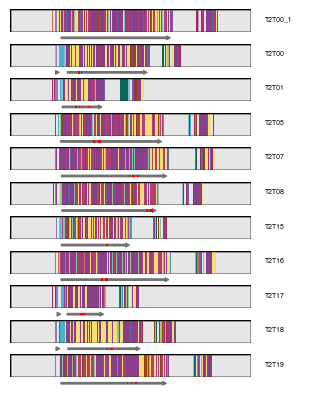

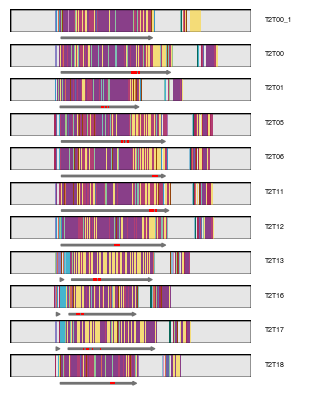

In [43]:
# Generate plots for each haplotype
print("Generating Haplotype 1 plot (CenMAP style)...")
result_hap1 = generate_haplotype_plot_cenmap_style(
    stv_data=stv_hap1,
    rm_data=rm_hap1,
    cdr_data=cdr_hap1,
    haplotype_name="hap1",
    output_dir=OUTPUT_DIR,
    width=PLOT_WIDTH_INCHES,
    color_map_file=STV_ANNOT_COLORS_FILE
)

print("Generating Haplotype 2 plot (CenMAP style)...")
result_hap2 = generate_haplotype_plot_cenmap_style(
    stv_data=stv_hap2,
    rm_data=rm_hap2,
    cdr_data=cdr_hap2,
    haplotype_name="hap2",
    output_dir=OUTPUT_DIR,
    width=PLOT_WIDTH_INCHES,
    color_map_file=STV_ANNOT_COLORS_FILE
)